In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report

In [2]:
from sklearn.naive_bayes import MultinomialNB

In [3]:
ds = pd.read_csv("tweets.csv")

In [4]:
ds.head()

,id,keyword,location,text,target
0,0,ablaze,NaN,"Communal violence in Bhainsa, Telangana. ""Ston...",1
1,1,ablaze,NaN,Telangana: Section 144 has been imposed in Bha...,1
2,2,ablaze,New York City,Arsonist sets cars ablaze at dealership https:...,1
3,3,ablaze,"Morgantown, WV",Arsonist sets cars ablaze at dealership https:...,1
4,4,ablaze,NaN,"""Lord Jesus, your love brings freedom and pard...",0


In [5]:
ds.tail()

,id,keyword,location,text,target
11365,11365,wrecked,Blue State in a red sea,Media should have warned us well in advance. T...,0
11366,11366,wrecked,arohaonces,i feel directly attacked 💀 i consider moonbin ...,0
11367,11367,wrecked,🇵🇭,i feel directly attacked 💀 i consider moonbin ...,0
11368,11368,wrecked,auroraborealis,"ok who remember ""outcast"" nd the ""dora"" au?? T...",0
11369,11369,wrecked,NaN,Jake Corway wrecked while running 14th at IRP.,1


In [6]:
ds.isna().any()

id          False
keyword     False
location     True
text        False
target      False
dtype: bool

In [7]:
ds.info()

<class 'pandas.DataFrame'>
RangeIndex: 11370 entries, 0 to 11369
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   id        11370 non-null  int64
 1   keyword   11370 non-null  str  
 2   location  7952 non-null   str  
 3   text      11370 non-null  str  
 4   target    11370 non-null  int64
dtypes: int64(2), str(3)
memory usage: 444.3 KB


In [8]:
ds.isna().sum()

id             0
keyword        0
location    3418
text           0
target         0
dtype: int64

In [9]:
pip install nltk

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [10]:
import re
import nltk


In [11]:
nltk.download("stopwords")


[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\DELL\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [12]:
from nltk.corpus import stopwords
stop_words = set(stopwords.words("english"))

In [13]:
def clean_text(text):

    text = text.lower()
    text = re.sub(r"http\\S+", "", text)
    text = re.sub(r"[^a-zA-Z\s]", "", text)
    text = text.strip()
    words = text.split()
    words = [word for word in words if word not in stop_words]

    return " ".join(words)

In [14]:
ds["clean_text"] = ds["text"].apply(clean_text)

In [15]:
ds.head()

,id,keyword,location,text,target,clean_text
0,0,ablaze,NaN,"Communal violence in Bhainsa, Telangana. ""Ston...",1,communal violence bhainsa telangana stones pel...
1,1,ablaze,NaN,Telangana: Section 144 has been imposed in Bha...,1,telangana section imposed bhainsa january clas...
2,2,ablaze,New York City,Arsonist sets cars ablaze at dealership https:...,1,arsonist sets cars ablaze dealership httpstcog...
3,3,ablaze,"Morgantown, WV",Arsonist sets cars ablaze at dealership https:...,1,arsonist sets cars ablaze dealership httpstcog...
4,4,ablaze,NaN,"""Lord Jesus, your love brings freedom and pard...",0,lord jesus love brings freedom pardon fill hol...


In [17]:
from sklearn.feature_extraction.text import TfidfVectorizer

In [19]:
X = ds["clean_text"]
y = ds["target"]

In [20]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [21]:
tfidf = TfidfVectorizer(
    stop_words='english',
    max_features=5000,
    ngram_range=(1,2)
)

In [22]:
X_train_tfidf = tfidf.fit_transform(X_train)

In [23]:
X_test_tfidf = tfidf.transform(X_test)

In [24]:
print(X_train_tfidf.shape)
print(X_test_tfidf.shape)

(9096, 5000)
(2274, 5000)


In [25]:
model = MultinomialNB(alpha=0.1)
model.fit(X_train_tfidf, y_train)

,"alpha alpha: float or array-like of shape (n_features,), default=1.0Additive (Laplace/Lidstone) smoothing parameter(set alpha=0 and force_alpha=True, for no smoothing).",0.1
,"force_alpha force_alpha: bool, default=TrueIf False and alpha is less than 1e-10, it will set alpha to1e-10. If True, alpha will remain unchanged. This may causenumerical errors if alpha is too close to 0... versionadded:: 1.2.. versionchanged:: 1.4 The default value of `force_alpha` changed to `True`.",True
,"fit_prior fit_prior: bool, default=TrueWhether to learn class prior probabilities or not.If false, a uniform prior will be used.",True
,"class_prior class_prior: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None


In [26]:
prediction = model.predict(X_test_tfidf)

In [27]:
accuracy = accuracy_score(y_test, prediction)

print("Accuracy :", accuracy)

Accuracy : 0.8970976253298153


In [28]:
print(classification_report(y_test, prediction))

              precision    recall  f1-score   support

           0       0.91      0.97      0.94      1878
           1       0.82      0.53      0.64       396

    accuracy                           0.90      2274
   macro avg       0.86      0.75      0.79      2274
weighted avg       0.89      0.90      0.89      2274



In [29]:
sample = ["massive earthquake destroyed many buildings"]

sample_tfidf = tfidf.transform(sample)

result = model.predict(sample_tfidf)

print(result)

[1]


In [30]:
sample2 = ["i love watching football with friends"]

sample2_tfidf = tfidf.transform(sample2)

result2 = model.predict(sample2_tfidf)

print(result2)

[0]


In [31]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, prediction)
cm

array([[1831,   47],
       [ 187,  209]])

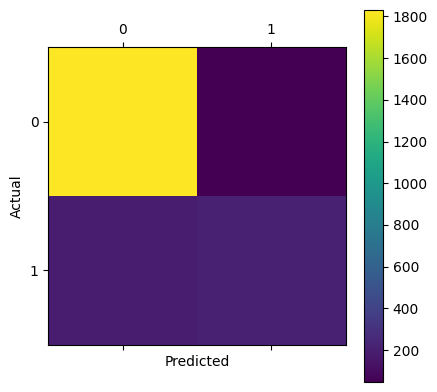

In [32]:
import matplotlib.pyplot as plt

plt.matshow(cm)

plt.colorbar()

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [34]:
samples = [

    "massive earthquake destroyed many buildings",
    "forest fire spreading rapidly near village",
    "heavy flood affected thousands of people",
    "cyclone warning issued in coastal area",
    "people trapped after bridge collapse",
    "tsunami alert announced by government",

    "i love watching football with friends",
    "today is a beautiful sunny day",
    "going to college for my exams",
    "watching movies and eating popcorn",
    "happy birthday have a wonderful day",
    "playing games with my teammates",
    "flood ruined the city drastically, please help us",
    "flood affects the building",
    "flood flood flood",
    "tsunami destroys the city",
    "earthquake destroys the city massively",
    "tsunami damages the roads and houses"

]

for text in samples:

    clean_sample = clean_text(text)

    vector = tfidf.transform([clean_sample])

    result = model.predict(vector)[0]

    if result == 1:
        print(f"Disaster Tweet  -->  {text}")

    else:
        print(f"Non-Disaster Tweet  -->  {text}")

Disaster Tweet  -->  massive earthquake destroyed many buildings
Disaster Tweet  -->  forest fire spreading rapidly near village
Disaster Tweet  -->  heavy flood affected thousands of people
Disaster Tweet  -->  cyclone warning issued in coastal area
Non-Disaster Tweet  -->  people trapped after bridge collapse
Non-Disaster Tweet  -->  tsunami alert announced by government
Non-Disaster Tweet  -->  i love watching football with friends
Non-Disaster Tweet  -->  today is a beautiful sunny day
Non-Disaster Tweet  -->  going to college for my exams
Non-Disaster Tweet  -->  watching movies and eating popcorn
Non-Disaster Tweet  -->  happy birthday have a wonderful day
Non-Disaster Tweet  -->  playing games with my teammates
Non-Disaster Tweet  -->  flood ruined the city drastically, please help us
Non-Disaster Tweet  -->  flood affects the building
Non-Disaster Tweet  -->  flood flood flood
Non-Disaster Tweet  -->  tsunami destroys the city
Disaster Tweet  -->  earthquake destroys the city m